# Research: how fit error changes with the number of points

This notebook sweeps all detected injections over beginning points 1 to 3 and point count, then saves a separate RSS heatmap for each injection in `research/output`.

In [19]:
from pathlib import Path
import importlib.util
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pha_lib").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pha_lib")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pha_lib import io
from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections

ADAPTIVE_PATH = ROOT / "adaptive points" / "adaptive point selection.py"
spec = importlib.util.spec_from_file_location("adaptive_point_selection", str(ADAPTIVE_PATH))
adaptive_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(adaptive_mod)

# INPUT = ROOT / "data" / "test" / "modified txt-s" / "unitedc_62_239.txt"
INPUT = ROOT / "data" / "test"
OUT_DIR = ROOT / "research" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LINE_E = 6660.0
HALF_W = 60.0
CHANNEL_ID = 2
MIN_POINTS = 2
START_POINT_MIN = 1
START_POINT_MAX = 3

print(f"Project root: {ROOT}")
print(f"Output dir: {OUT_DIR}")
print(f"Input file: {INPUT}")

Project root: D:\ℱ Sci\IFPiLM\1st task
Output dir: D:\ℱ Sci\IFPiLM\1st task\research\output
Input file: D:\ℱ Sci\IFPiLM\1st task\data\test


In [20]:
discharge = io.load_test_folder(INPUT, discharge_id="united_62_239")
channel = discharge.channels[CHANNEL_ID]
trace = integrate_energy_window(channel, LINE_E, HALF_W)
injections = detect_injections(trace, LINE_E)

if not injections:
    raise RuntimeError("No injections detected for the chosen channel")

print(f"Loaded discharge: {discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(injections)} injections detected")

heatmap_runs = []
for injection in injections:
    min_points = MIN_POINTS
    max_points = max(min_points, injection.finish_frame - injection.start_frame)
    print("")
    print(f"Using injection #{injection.injection_no} spanning frames {injection.start_frame}..{injection.finish_frame}")
    print(f"Sweeping beginning points {START_POINT_MIN} to {START_POINT_MAX} and point counts from {min_points} to {max_points}")

    rows = adaptive_mod.sweep_injection_windows(
        trace,
        injection,
        min_points=min_points,
        max_points=max_points,
        start_point_min=START_POINT_MIN,
        start_point_max=START_POINT_MAX,
    )
    df = pd.DataFrame(rows)

    cols_to_show = ["start_point", "start_frame", "n_points", "success", "A", "A_err", "tau", "tau_err", "C", "C_err", "rss", "message"]
    print(df[cols_to_show].to_string(index=False))

    csv_path = OUT_DIR / f"sweep_channel{CHANNEL_ID}_inj{injection.injection_no}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved table -> {csv_path}")

    success_df = df[df["success"]].copy()
    if not success_df.empty:
        best_row = success_df.sort_values("rss").iloc[0]
        print("")
        print("Best fit by RSS:")
        print(best_row[["start_point", "start_frame", "n_points", "A", "A_err", "tau", "tau_err", "C", "C_err", "rss"]].to_string())

    heatmap_runs.append(
        {
            "injection": injection,
            "df": df,
            "min_points": min_points,
            "max_points": max_points,
        }
    )

Loaded discharge: united_62_239
Channel 2: 5 injections detected

Using injection #1 spanning frames 63..67
Sweeping start frame and point counts from 2 to 4
 start_frame  n_points  success          A     A_err       tau  tau_err    C  C_err          rss message
          63         2     True 171.000000       inf 84.999020      inf 58.0    0.0 29401.977254      ok
          63         3     True 184.702405 47.719428  2.852852 2.280707 58.0    0.0  3799.511688      ok
          63         4     True 189.197765 38.286262  2.276727 1.021201 58.0    0.0  3271.884053      ok
          64         2     True 169.000000       inf  1.029850      inf 58.0    0.0    14.162529      ok
          64         3     True 168.646829  2.942040  1.062661 0.043148 58.0    0.0     8.780327      ok
          65         2     True  64.000000       inf  1.209660      inf 58.0    0.0     0.000000      ok
Saved table -> D:\ℱ Sci\IFPiLM\1st task\research\output\sweep_channel2_inj1.csv

Best fit by RSS:
start_fra

D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:219: OptimizeWarning: Covariance of the parameters could not be estimated
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:219: OptimizeWarning: Covariance of the parameters could not be estimated
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:219: OptimizeWarning: Covariance of the parameters could not be estimated
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:219: OptimizeWarning: Covariance of the parameters could not be estimated
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:219: OptimizeWarning: Covariance of the parameters could not be estimated


Saved table -> D:\ℱ Sci\IFPiLM\1st task\research\output\sweep_channel2_inj5.csv

Best fit by RSS:
start_frame         290
n_points              2
A                  61.0
A_err               inf
tau            1.409093
tau_err             inf
C                  58.0
C_err               0.0
rss                 0.0


Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\heatmap_channel2_inj1.png


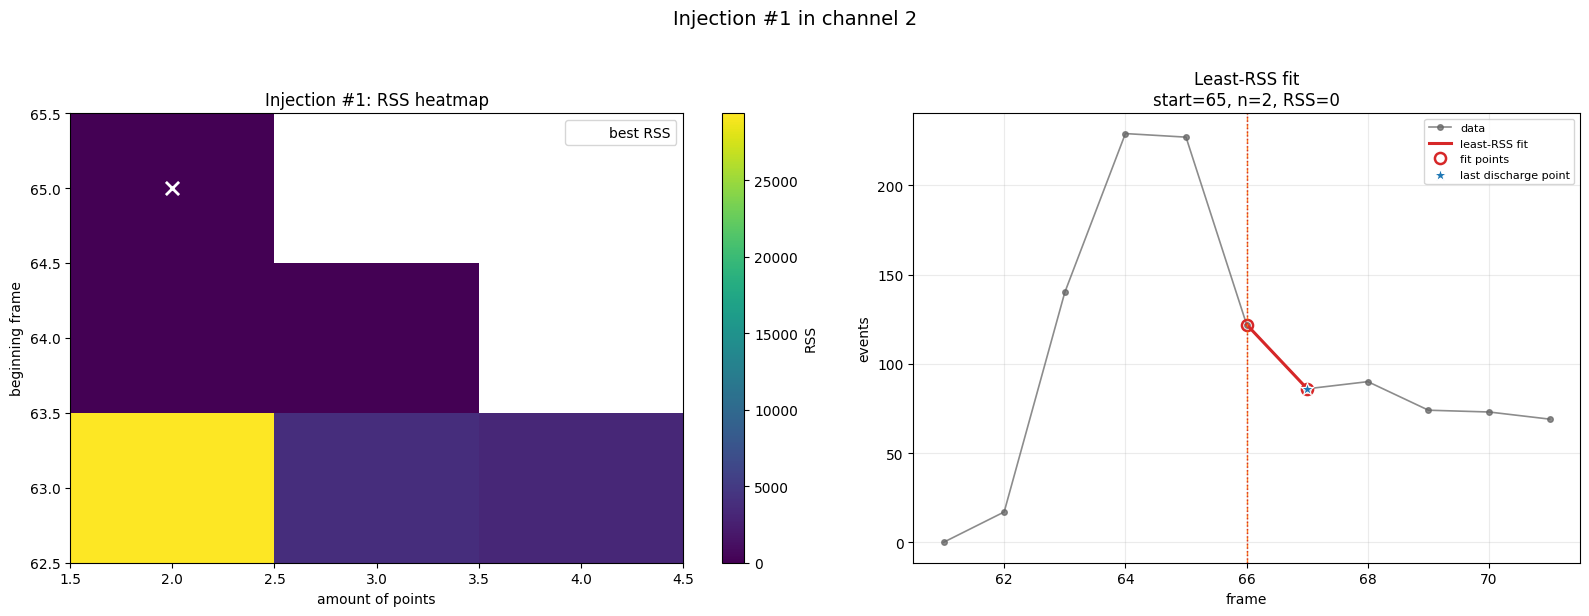

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\heatmap_channel2_inj2.png


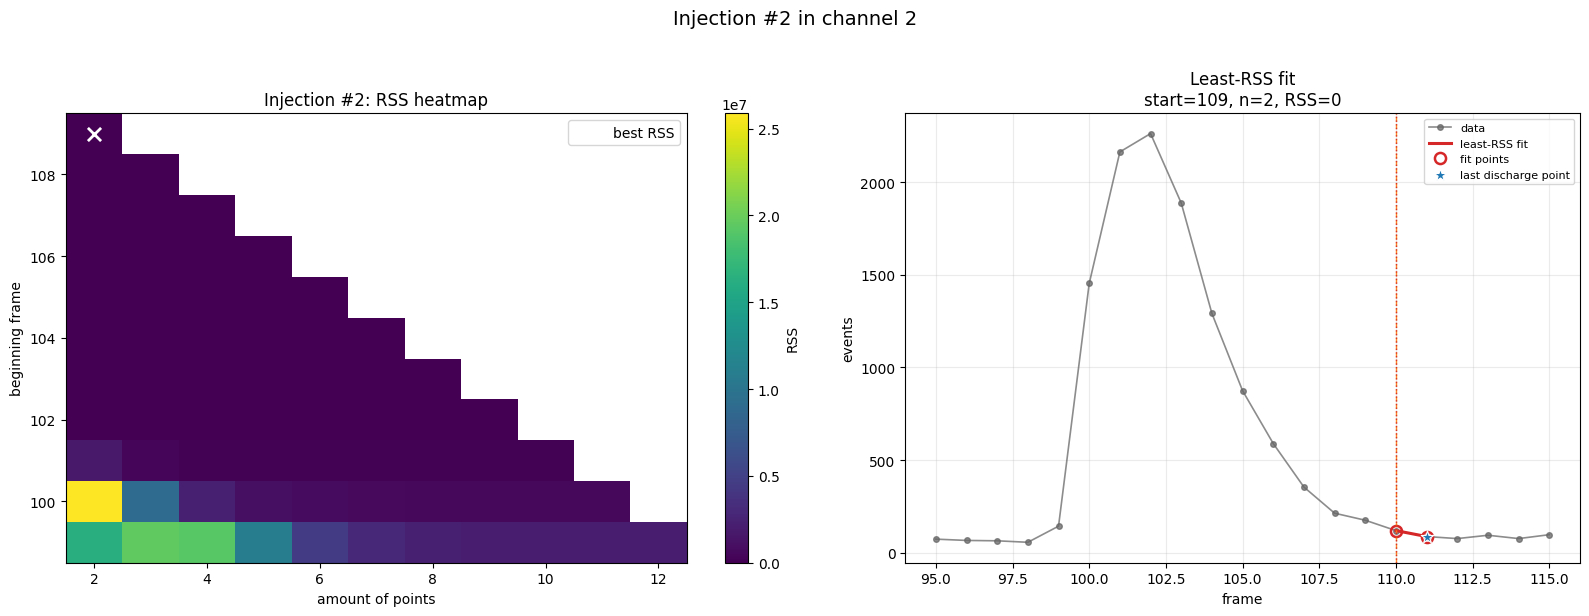

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\heatmap_channel2_inj3.png


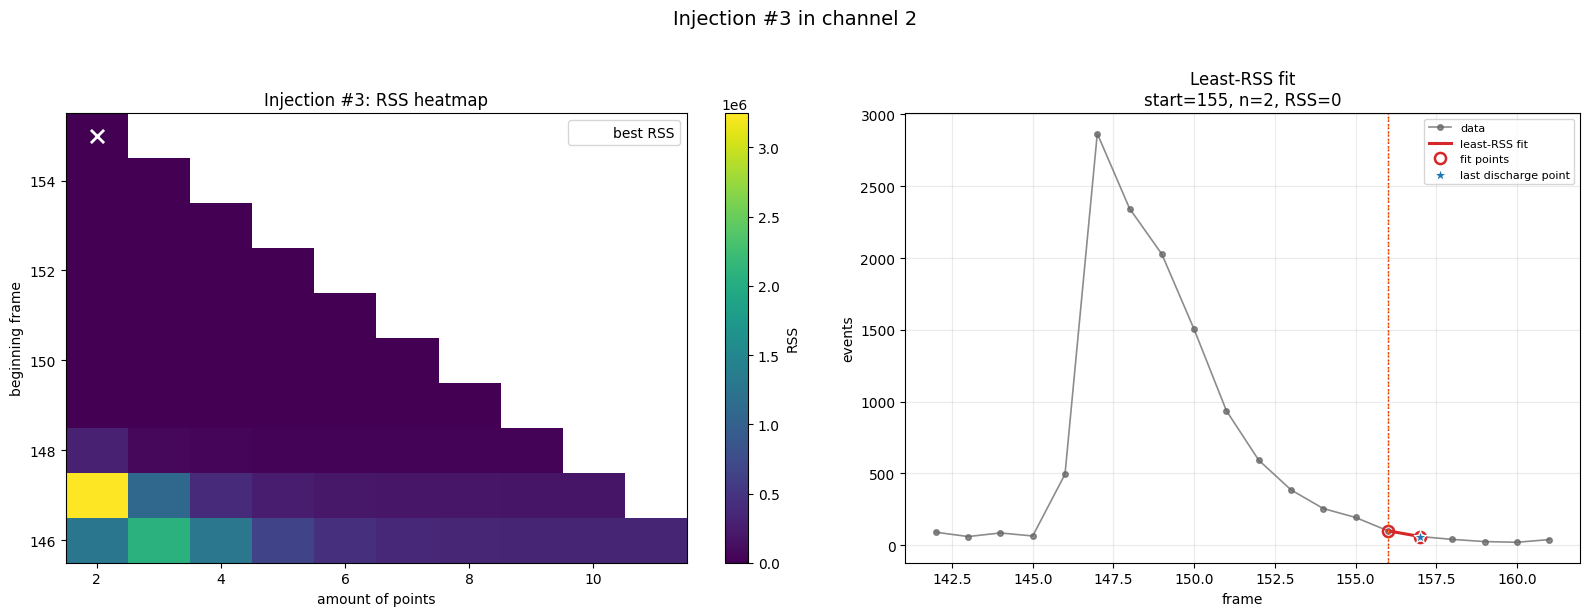

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\heatmap_channel2_inj4.png


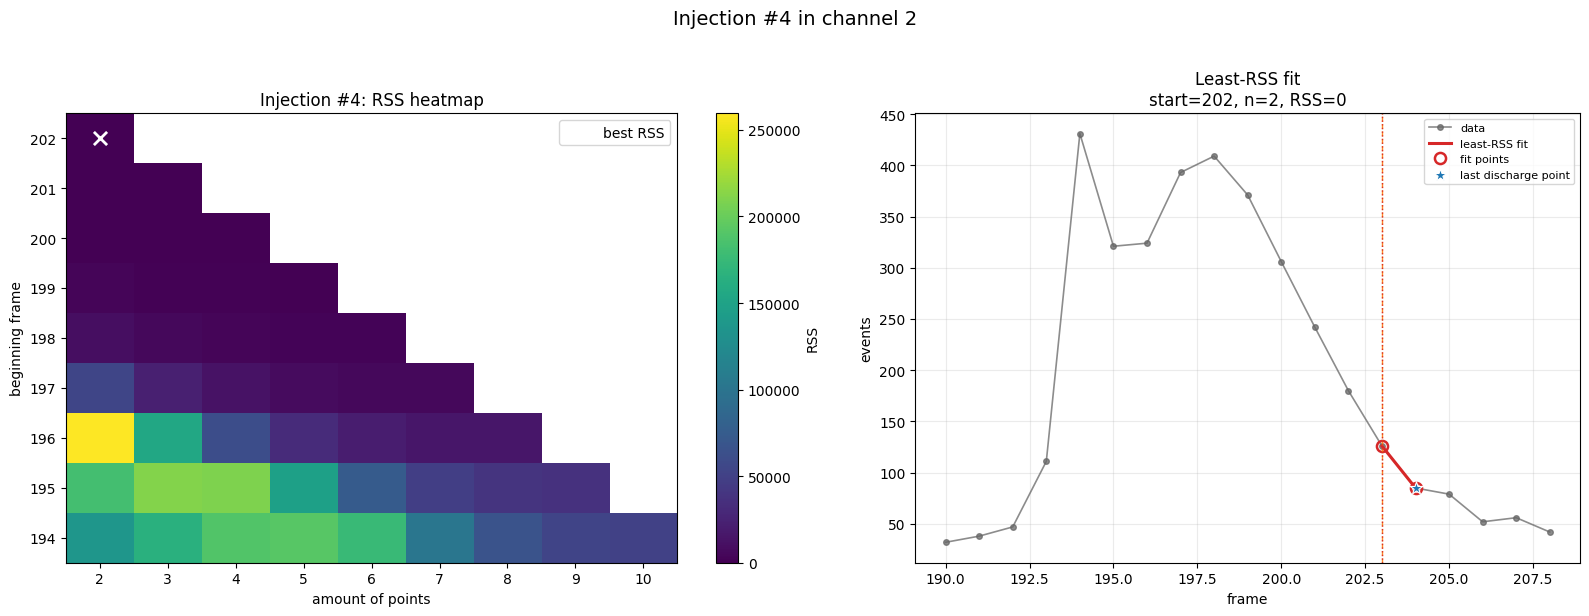

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\heatmap_channel2_inj5.png


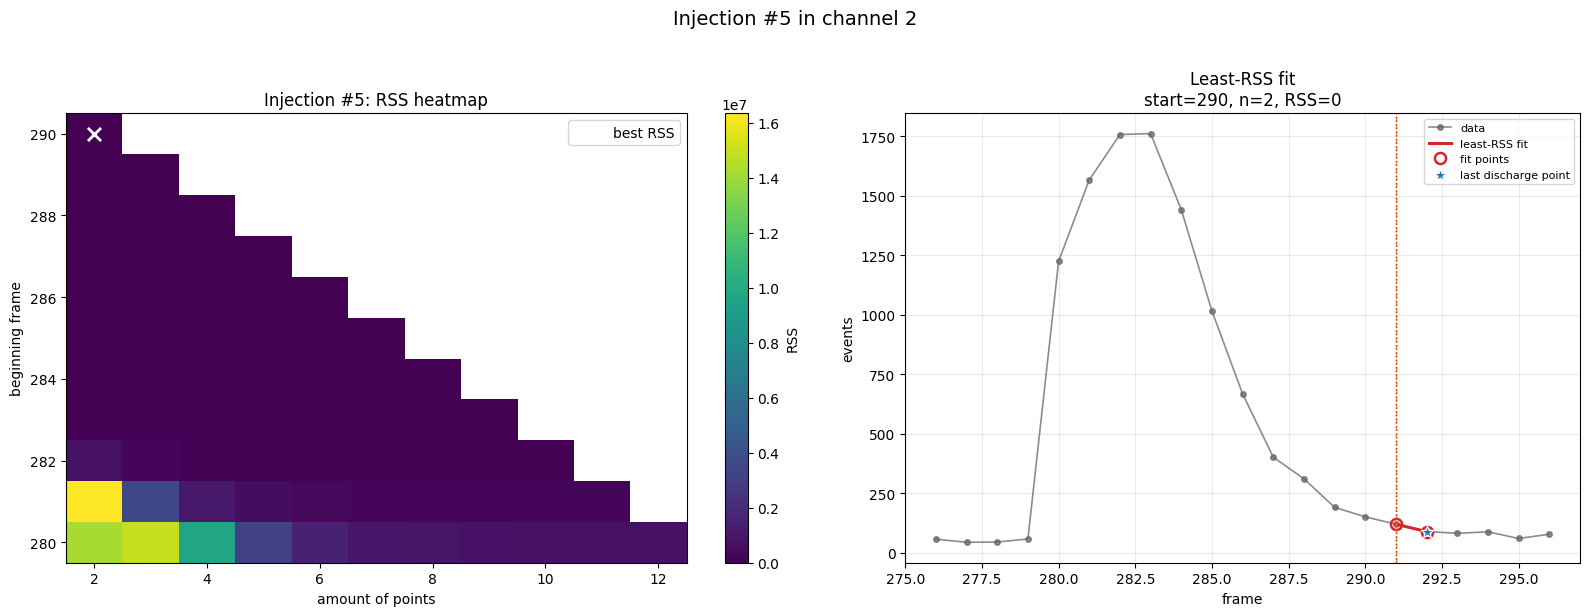

In [22]:
def format_value(value: float, error: float, digits: int = 2) -> str:
    if pd.isna(value):
        return "nan"
    if pd.isna(error):
        return f"{value:.{digits}f}"
    return f"{value:.{digits}f} ± {error:.{digits}f}"


if not heatmap_runs:
    raise RuntimeError("No injection runs available to plot")

for run in heatmap_runs:
    injection = run["injection"]
    df = run["df"]
    min_points = run["min_points"]
    max_points = run["max_points"]

    success_df = df[df["success"]].copy().reset_index(drop=True)
    if success_df.empty:
        print(f"Skipping injection #{injection.injection_no}: no successful fits")
        continue

    start_values = np.sort(success_df["start_point"].astype(int).unique())
    point_values = np.arange(min_points, max_points + 1, dtype=int)
    rss_grid = np.full((len(start_values), len(point_values)), np.nan, dtype=float)

    start_to_row = {start_point: idx for idx, start_point in enumerate(start_values)}
    point_to_col = {n_points: idx for idx, n_points in enumerate(point_values)}

    for _, row in success_df.iterrows():
        start_point = int(row["start_point"])
        n_points = int(row["n_points"])
        rss_grid[start_to_row[start_point], point_to_col[n_points]] = float(row["rss"])

    best_row = success_df.sort_values("rss").iloc[0]
    best_start_point = int(best_row["start_point"])
    best_start_frame = int(best_row["start_frame"])
    best_n_points = int(best_row["n_points"])
    best_end_frame = best_start_frame + best_n_points - 1

    fn = trace.frame_numbers
    v = trace.values
    best_start_idx = int(np.where(fn == int(best_start_frame + 1))[0][0])
    best_eval_end_idx = int(np.where(fn == int(injection.finish_frame))[0][0]) + 1
    best_eval_end_idx = max(best_eval_end_idx, best_start_idx + best_n_points)
    best_t_fit = fn[best_start_idx:best_start_idx + best_n_points].astype(float)
    best_y_fit = v[best_start_idx:best_start_idx + best_n_points]
    best_t_eval = fn[best_start_idx:best_eval_end_idx].astype(float)
    best_curve = best_row["A"] * np.exp(-(best_t_eval - best_row["t_0"]) / best_row["tau"]) + best_row["C"]

    masked_rss = np.ma.masked_invalid(rss_grid)
    fig, (ax_heat, ax_fit) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.15, 1.0]})
    extent = [
        point_values[0] - 0.5,
        point_values[-1] + 0.5,
        start_values[0] - 0.5,
        start_values[-1] + 0.5,
    ]
    im = ax_heat.imshow(
        masked_rss,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=extent,
    )
    fig.colorbar(im, ax=ax_heat, label="RSS")

    ax_heat.scatter(
        [best_n_points],
        [best_start_point],
        c="white",
        s=90,
        marker="x",
        linewidths=2,
        label="best RSS",
    )
    ax_heat.set_xlabel("amount of points")
    ax_heat.set_ylabel("beginning point number")
    ax_heat.set_title(f"Injection #{injection.injection_no}: RSS heatmap")
    ax_heat.legend(loc="upper right")

    context_lo = max(0, injection.start_frame - 4)
    context_hi = min(int(fn[-1]), injection.finish_frame + 4)
    context_mask = (fn >= context_lo) & (fn <= context_hi)
    ax_fit.plot(fn[context_mask], v[context_mask], "o-", ms=4, lw=1.2, color="0.4", alpha=0.75, label="data")
    ax_fit.plot(best_t_eval, best_curve, color="tab:red", lw=2.2, label="least-RSS fit")
    ax_fit.plot(best_t_fit, v[best_start_idx:best_start_idx + best_n_points], "o", ms=8, mfc="none", mec="tab:red", mew=1.8, label="fit points")
    ax_fit.scatter(
        [fn[int(np.where(fn == int(injection.finish_frame))[0][0])]],
        [v[int(np.where(fn == int(injection.finish_frame))[0][0])]],
        s=90,
        marker="*",
        color="tab:blue",
        edgecolors="white",
        linewidths=0.8,
        zorder=5,
        label="last discharge point",
    )
    ax_fit.axvline(best_start_frame + 1, color="tab:orange", ls="--", lw=1, alpha=0.9)
    ax_fit.axvline(best_end_frame, color="tab:red", ls=":", lw=1, alpha=0.9)
    ax_fit.set_xlabel("frame")
    ax_fit.set_ylabel("events")
    ax_fit.set_title(
        f"Least-RSS fit\nstart point={best_start_point}, n={best_n_points}, RSS={best_row['rss']:.3g}"
    )
    ax_fit.grid(alpha=0.25)
    ax_fit.legend(fontsize=8)

    fig.suptitle(
        f"Injection #{injection.injection_no} in channel {CHANNEL_ID}",
        y=1.02,
        fontsize=14,
    )
    fig.tight_layout()

    fig_path = OUT_DIR / f"heatmap_channel{CHANNEL_ID}_inj{injection.injection_no}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure -> {fig_path}")
    display(fig)
    plt.close(fig)